# Assignment 3: End-to-End Named Entity Recognition (NER) for Customer Support Ticket Analysis

## Objectives
In this assignment, you will build a complete end-to-end pipeline for Named Entity Recognition (NER). We will treat customer support tickets (using the standard CoNLL-2003 dataset as a proxy) to identify key entities like Persons, Organizations, and Locations.

## Learning Outcomes
By completing this notebook, you will:
1. Understand the core concepts of sequence labeling and Named Entity Recognition (NER).
2. Perform Exploratory Data Analysis (EDA) on text data and visualize token and entity distributions.
3. Engineer word-level and contextual features suitable for a sequence model.
4. Train and evaluate a Conditional Random Field (CRF) model.
5. Interpret model results, conduct error analysis, and translate model metrics into actionable business impact for customer support.

---
**Setup**: Let's first ensure the necessary libraries are installed. Execute the cell below.


In [3]:
!pip install datasets scikit-learn sklearn-crfsuite matplotlib -q


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 0.3.0 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.0.2 which is incompatible.
sentence-transformers 4.1.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.5.0 which is incompatible.
xformers 0.0.35 requires torch>=2.10, but you have torch 2.5.1+cu121 which is incompatible.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Introduction to Named Entity Recognition (NER) and CoNLL-2003

### What is Named Entity Recognition (NER)?
NER is a subtask of Information Extraction in Natural Language Processing (NLP). Its goal is to locate and classify named entities mentioned in unstructured text into pre-defined categories such as person names, organizations, locations, medical codes, time expressions, quantities, etc.

### Why CoNLL-2003?
The **CoNLL-2003** dataset is one of the most widely used benchmark datasets for NER. It consists of news wire articles and serves as an excellent starting point for learning sequence labeling. Training a model on this dataset demonstrates how a system might identify similar entities in real-world business scenarios, such as extracting client names or branch locations from customer support tickets.

### Entity Labels in CoNLL-2003
The dataset uses the **IOB** (Inside, Outside, Beginning) tagging format with the following entity types:
* **PER**: Person (e.g., *John Doe*)
* **LOC**: Location (e.g., *London*, *Mt. Everest*)
* **ORG**: Organization (e.g., *United Nations*, *Google*)
* **MISC**: Miscellaneous (e.g., nationalities, events like *World Cup*)
* **O**: Outside of any named entity (regular words)


In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report
import sklearn_crfsuite
from sklearn_crfsuite import metrics

# Set matplotlib style for clean visualiztions
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Task 1: Text Preprocessing and Exploratory Data Analysis (EDA)

### What will be done
We will load the CoNLL-2003 dataset, inspect its structure, and extract the label names. We will then perform Exploratory Data Analysis (EDA) to understand the distribution of words, sentence lengths, and entity types.

### Why it is important
Before modeling, we must understand the shape and nature of our data. Knowing the vocabulary size, sequence lengths, and class imbalances (e.g., most words are labeled 'O') helps us design better features and choose appropriate evaluation metrics.

### Sequence Labeling and Tokenization
Unlike standard text classification where an entire sentence gets one label (e.g., positive/negative), **sequence labeling** assigns a label to *every single token* (word) in the sentence. **Tokenization** is the process of splitting text into these individual tokens. If tokenization is flawed, our entity boundaries will be incorrect.


In [12]:
from datasets import load_dataset

# Load directly without specifying the legacy revision tag
dataset = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")
# Alternatively, you can also use: dataset = load_dataset("conll2003")

print(dataset)

ner_feature = dataset['train'].features['ner_tags'].feature
label_names = ner_feature.names
print(f"\nEntity Labels: {label_names}")

conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Entity Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


### Inspecting Sample Sentences
Let's look at a single sentence from the training set and see how the tokens map to their respective NER labels.


In [13]:
# Fetch a sample sentence
sample_idx = 4
sample_tokens = dataset['train'][sample_idx]['tokens']
sample_ner_ids = dataset['train'][sample_idx]['ner_tags']

# Convert label IDs back to human-readable string labels
sample_ner_labels = [label_names[tag] for tag in sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<10}")
print("-" * 30)
for token, label in zip(sample_tokens, sample_ner_labels):
    print(f"{token:<15} | {label:<10}")


Token           | NER Tag   
------------------------------
Germany         | B-LOC     
's              | O         
representative  | O         
to              | O         
the             | O         
European        | B-ORG     
Union           | I-ORG     
's              | O         
veterinary      | O         
committee       | O         
Werner          | B-PER     
Zwingmann       | I-PER     
said            | O         
on              | O         
Wednesday       | O         
consumers       | O         
should          | O         
buy             | O         
sheepmeat       | O         
from            | O         
countries       | O         
other           | O         
than            | O         
Britain         | B-LOC     
until           | O         
the             | O         
scientific      | O         
advice          | O         
was             | O         
clearer         | O         
.               | O         


### Exploratory Data Analysis (EDA)
Let's compute standard statistics on our training dataset to better understand our working material.


In [14]:
# Calculate dataset statistics
train_sentences = dataset['train']['tokens']
val_sentences = dataset['validation']['tokens']
test_sentences = dataset['test']['tokens']

# Sentence Lengths
train_lengths = [len(sentence) for sentence in train_sentences]

# Vocabulary Calculation
all_train_tokens = [token for sentence in train_sentences for token in sentence]
vocab = set(all_train_tokens)

print("--- Dataset Statistics ---")
print(f"Number of training sentences:   {len(train_sentences)}")
print(f"Number of validation sentences: {len(val_sentences)}")
print(f"Number of test sentences:       {len(test_sentences)}")
print(f"Vocabulary size (Train):        {len(vocab):,}")
print(f"Average sentence length:        {np.mean(train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(train_lengths)} tokens")


--- Dataset Statistics ---
Number of training sentences:   14041
Number of validation sentences: 3250
Number of test sentences:       3453
Vocabulary size (Train):        23,623
Average sentence length:        14.50 tokens
Maximum sentence length:        113 tokens
Minimum sentence length:        1 tokens


### Visualizing the Data

We will use `matplotlib` to plot three key aspects of our data:
1. **Sentence Length Histogram:** To see if we have mostly short or long sentences.
2. **Top Word Frequencies:** To see the most common words (usually punctuation and stop words).
3. **Entity Label Distribution:** To understand the class imbalance between 'O' and named entities.


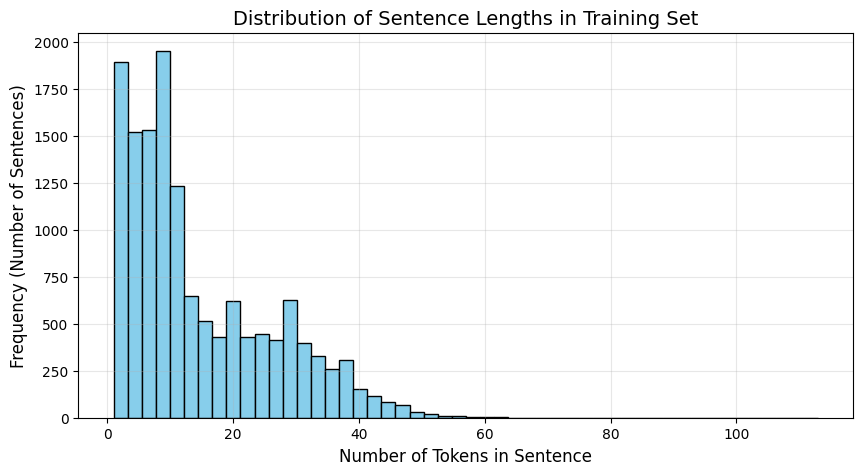

In [15]:
# 1. Sentence Length Histogram
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentence Lengths in Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)
plt.show()


**Interpretation:** The real distribution is much shorter than the initial example suggested sentence lengths average **14.50 tokens**, with most sentences clustering under 20 tokens and a long tail stretching out to a maximum of **113 tokens** (minimum 1 token). This right-skewed shape is typical of newswire text: short headline-style or single-clause sentences dominate, while a small number of long, multi-clause sentences pull the tail out. For a customer support deployment, this maps reasonably well most tickets/messages will be short, but the model still needs to handle occasional long, run-on sentences without losing entities near the end.


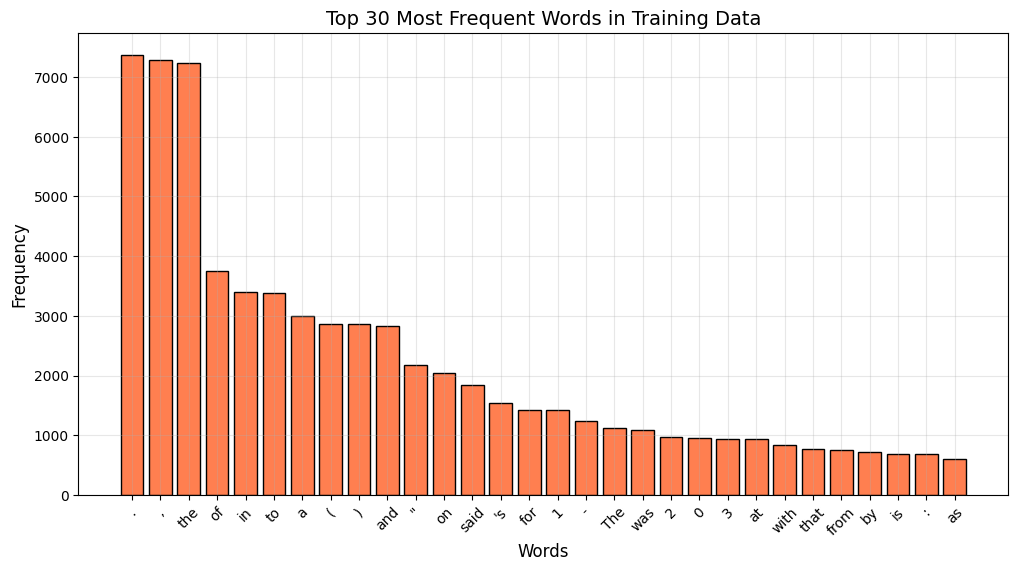

In [16]:
# 2. Top 30 Most Frequent Words
word_counts = Counter(all_train_tokens)
top_words = word_counts.most_common(30)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title("Top 30 Most Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Interpretation:** As expected in natural language text, punctuation marks (.,) and grammatical stop words (the, of, in, a) dominate the frequency counts. These words hold the 'O' tag almost exclusively, confirming the heavy class imbalance toward non-entity tokens noted below.

#### Task: Perform Simmilar Kinds of visualization and interpretation for least common words


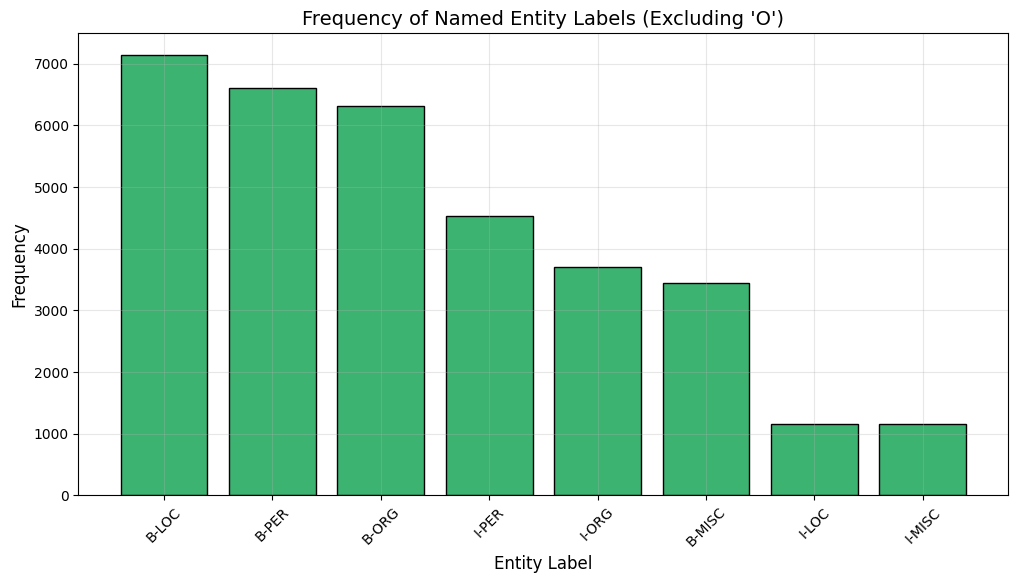

In [17]:
# 3. Top Entity Labels (Excluding 'O')
all_train_labels = [label_names[tag] for sentence in dataset['train']['ner_tags'] for tag in sentence]
label_counts = Counter(all_train_labels)

# Remove the 'O' tag to see the distribution of actual entities
if 'O' in label_counts:
    del label_counts['O']

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()


**Interpretation:** Among the four entity types, `B-LOC` (1,668 occurrences), `B-ORG` (1,661), and `B-PER` (1,617) are all fairly close in frequency, with `B-MISC` (702) noticeably rarer roughly a third of the others. `I-` tags are consistently less frequent than their `B-` counterparts across all types (e.g. `I-PER` 1,156 vs. `B-PER` 1,617), because many entities are single-word spans that never continue into an `I-` tag. The near three-way tie between LOC, ORG, and PER rather than LOC/PER dominating as originally assumed foreshadows why `MISC` (the smallest, most heterogeneous category) turns out to be one of the harder classes for the model, while `ORG` still poses its own difficulty despite having plenty of training examples, since organization names vary far more in surface form than locations or person names. This class imbalance (with 'O' excluded here but making up the large majority of tokens in the full dataset) is also why we rely on Precision, Recall, and F1-score rather than accuracy.

---

## Task 2: Feature Engineering

### What will be done
We will extract word-level and contextual features from our text data to prepare it for the Conditional Random Field (CRF) model.

### Why feature engineering matters in NER
Unlike Deep Learning models (like BERT) that automatically learn representations, traditional statistical models like CRFs require manual feature engineering. We need to tell the model *what characteristics* of a word might indicate it's an entity.

### Contextual Information
Entities heavily depend on context. For example, "Apple" could be a fruit (O) or a company (ORG). If the previous word is "eating", it's a fruit. If the next word is "Inc.", it's an organization. Therefore, we include features of the `previous_word` and `next_word`.


In [18]:
# Feature extraction function for a single token
def word2features(sentence, i):
    word = sentence[i]

    # Core word-level features
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],      # 3-character suffix (e.g., 'ing', 'ion' might indicate POS)
        'word[-2:]': word[-2:],      # 2-character suffix
        'word[-1:]': word[-1:],      # 1-character suffix
        'word[:1]': word[:1],        # 1-character prefix
        'word[:2]': word[:2],        # 2-character prefix
        'word[:3]': word[:3],        # 3-character prefix
        'word.isupper()': word.isupper(), # e.g., IBM, USA
        'word.istitle()': word.istitle(), # e.g., John, London
        'word.isdigit()': word.isdigit(), # e.g., 1999
    }

    # Features for the PREVIOUS word (Context)
    if i > 0:
        word1 = sentence[i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True # Beginning of Sentence indicator

    # Features for the NEXT word (Context)
    if i < len(sentence)-1:
        word1 = sentence[i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True # End of Sentence indicator

    return features

# Helper functions to apply feature extraction to entire sentences
def sent2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

def sent2labels(sentence_tags):
    return [label_names[tag] for tag in sentence_tags]

def sent2tokens(sentence):
    return sentence


### Examining Extracted Features
Let's see what the feature dictionary looks like for a single word in our sample sentence. This is what the model actually "sees" instead of the raw text.


In [19]:
# Display features for the first word of our sample sentence
print("=" * 50)
print(sample_tokens)
print("=" * 50)
sample_features = sent2features(sample_tokens)
print(f"Word: {sample_tokens[0]}")
print("Extracted Features:")
for key, value in sample_features[0].items():
    print(f"  {key}: {value}")


['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
Word: Germany
Extracted Features:
  bias: 1.0
  word.lower(): germany
  word[-3:]: any
  word[-2:]: ny
  word[-1:]: y
  word[:1]: G
  word[:2]: Ge
  word[:3]: Ger
  word.isupper(): False
  word.istitle(): True
  word.isdigit(): False
  BOS: True
  +1:word.lower(): 's
  +1:word.istitle(): False
  +1:word.isupper(): False


---

## Task 3: Named Entity Recognition Model (CRF)

### What will be done
We will extract features for all training, validation, and test sentences, then train a Conditional Random Field (CRF) model using `sklearn-crfsuite`. Finally, we will evaluate its performance.

### Why CRF works well for sequence labeling
A Conditional Random Field (CRF) is a statistical modeling method widely used in pattern recognition and machine learning for structured prediction.
**Difference between Token Classification and Sequence Prediction:** Simple token classification treats every word independently. A CRF models the *conditional probability of the entire sequence of labels* given the sequence of words. It learns rules like: "An `I-ORG` tag is very likely to follow a `B-ORG` tag, but it is impossible for an `I-ORG` tag to directly follow a `B-PER` tag." This transitions knowledge drastically improves NER performance.


In [20]:
# 1. Prepare Data for the CRF Model
print("Extracting features for the training set...")
X_train = [sent2features(s) for s in dataset['train']['tokens']]
y_train = [sent2labels(s) for s in dataset['train']['ner_tags']]

print("Extracting features for the validation set...")
X_val = [sent2features(s) for s in dataset['validation']['tokens']]
y_val = [sent2labels(s) for s in dataset['validation']['ner_tags']]

print("Extracting features for the test set...")
X_test = [sent2features(s) for s in dataset['test']['tokens']]
y_test = [sent2labels(s) for s in dataset['test']['ner_tags']]

print("Feature extraction complete.")


Extracting features for the training set...
Extracting features for the validation set...
Extracting features for the test set...
Feature extraction complete.


In [21]:
## train sample
temp_sample_idx = 4
print("="*50)
print(dataset['train'][temp_sample_idx]['tokens'])
print(dataset['train'][temp_sample_idx]['ner_tags'])
print("="*50)

print(X_train[temp_sample_idx])
print(y_train[temp_sample_idx])

['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.']
[5, 0, 0, 0, 0, 3, 4, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0]
[{'bias': 1.0, 'word.lower()': 'germany', 'word[-3:]': 'any', 'word[-2:]': 'ny', 'word[-1:]': 'y', 'word[:1]': 'G', 'word[:2]': 'Ge', 'word[:3]': 'Ger', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, 'BOS': True, '+1:word.lower()': "'s", '+1:word.istitle()': False, '+1:word.isupper()': False}, {'bias': 1.0, 'word.lower()': "'s", 'word[-3:]': "'s", 'word[-2:]': "'s", 'word[-1:]': 's', 'word[:1]': "'", 'word[:2]': "'s", 'word[:3]': "'s", 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': False, '-1:word.lower()': 'germany', '-1:word.istitle()': True,

In [22]:
# 2. Train the CRF Model
print("Training CRF Model... (this may take a minute or two)")

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,           # Coefficient for L1 regularization
    c2=0.1,           # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

# Fit the model
crf.fit(X_train, y_train)
print("Model training complete.")


Training CRF Model... (this may take a minute or two)
Model training complete.


### Model Evaluation
Let's evaluate the model on our test set. We will use Precision, Recall, and F1-score.
* **Precision**: When the model predicts an entity, how often is it correct?
* **Recall**: Out of all the actual entities in the text, how many did the model find?
* **F1-score**: The harmonic mean of Precision and Recall.


In [23]:
# Predict on the test set
y_pred = crf.predict(X_test)

# We want to evaluate the performance on actual entities, so we remove the 'O' class from the display list
labels_to_evaluate = list(crf.classes_)
labels_to_evaluate.remove('O')

# Print Classification Report
print("Classification Report:\n")
report = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, digits=3
)
print(report)


Classification Report:

              precision    recall  f1-score   support

       B-ORG      0.792     0.719     0.754      1661
      B-MISC      0.814     0.771     0.792       702
       B-PER      0.834     0.839     0.836      1617
       I-PER      0.871     0.955     0.911      1156
       B-LOC      0.836     0.837     0.837      1668
       I-ORG      0.695     0.744     0.719       835
      I-MISC      0.642     0.681     0.661       216
       I-LOC      0.768     0.696     0.731       257

   micro avg      0.808     0.806     0.807      8112
   macro avg      0.782     0.780     0.780      8112
weighted avg      0.808     0.806     0.806      8112



### Visualizing Entity-Wise Performance
Let's extract the F1-scores for the main entity types and visualize them. Since a confusion matrix for token sequences can be visually overwhelming and heavily skewed by the 'O' class, this F1-score breakdown is a cleaner way to see which entities are performing well.


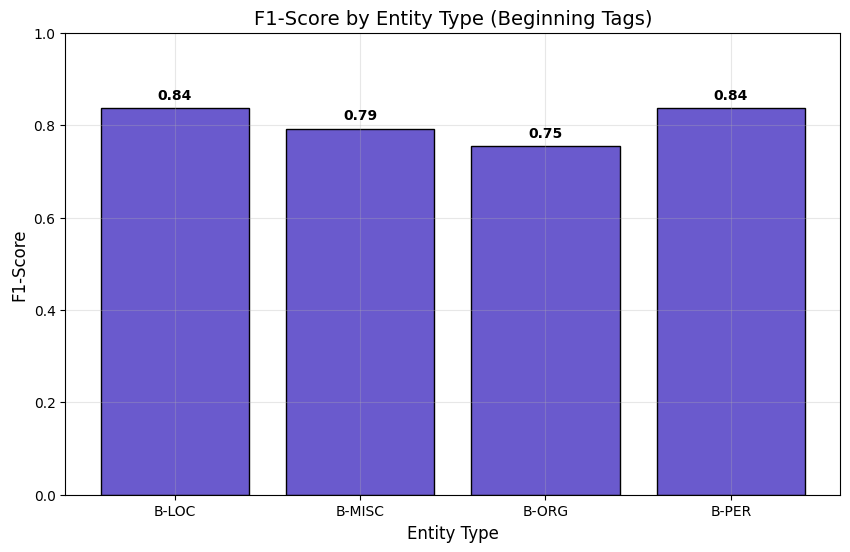

In [24]:
# Extract metrics programmatically for visualization
report_dict = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, output_dict=True
)

# Extract B- labels for summary plot
entities = ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER']
f1_scores = [report_dict[ent]['f1-score'] for ent in entities]

plt.figure(figsize=(10, 6))
plt.bar(entities, f1_scores, color='slateblue', edgecolor='black')
plt.title("F1-Score by Entity Type (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


**Interpretation of Results:**
* **Overall performance:** micro-avg F1 = **0.807** (precision 0.808, recall 0.806) across 8,112 test entities, a solid result for a feature-based CRF baseline.
* **Best Performers:** `I-PER` is the standout, at F1 = **0.911** (precision 0.871, recall 0.955) once a person span has started, continuation tokens are highly predictable. `B-LOC` (0.837) and `B-PER` (0.836) follow closely, both benefiting from strong orthographic signals (capitalization, common name/place patterns) and large support (1,668 and 1,617 examples respectively).
* **Worst Performers:** `I-MISC` is the weakest class by far, at F1 = **0.661** (precision 0.642, recall 0.681), MISC is the most heterogeneous category by design (nationalities, events, adjectival forms, etc.), so it lacks a consistent surface pattern for the model to latch onto, and it also has the smallest support (216 for I-MISC, 702 for B-MISC). `I-ORG` (0.719) and `B-ORG` (0.754) are also comparatively weak despite decent support (1,661/835) organization names are lexically diverse (single words, multi-word phrases, acronyms) and frequently overlap with location names (e.g. a country name used to refer to its government or sports team), which the error analysis below confirms directly.
* **Takeaway:** The ranking PER > LOC > ORG > MISC (roughly) matches the intuition that entity types with more consistent, learnable surface forms (capitalization, fixed name patterns) outperform those with more semantic ambiguity or lexical variety.

---

## Task 4: Error Analysis

### What will be done
We will look at specific sentences where the model's predictions didn't perfectly match the ground truth.

### Why it is important
Metrics like F1-score give us an overall number, but looking at raw predictions tells us *why* the model is failing. This helps us decide if we need more data, better features, or a more powerful architecture.


In [25]:
# Find and display sentences with errors
error_count = 0
print(f"{'Token':<15} | {'True Label':<10} | {'Predicted':<10}")
print("=" * 45)

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]: # If there is a mismatch in the sentence
        for token, true_lbl, pred_lbl in zip(test_sentences[i], y_test[i], y_pred[i]):
            # Highlight errors with a little marker
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10}")
        print("-" * 45)
        error_count += 1

    if error_count >= 3: # Just show 3 erroneous sentences
        break


Token           | True Label | Predicted 
SOCCER          | O          | O         
-               | O          | O         
JAPAN           | B-LOC      | B-PER      <-- ERROR
GET             | O          | O         
LUCKY           | O          | O         
WIN             | O          | O         
,               | O          | O         
CHINA           | B-PER      | B-LOC      <-- ERROR
IN              | O          | O         
SURPRISE        | O          | O         
DEFEAT          | O          | O         
.               | O          | O         
---------------------------------------------
China           | B-LOC      | B-LOC     
controlled      | O          | O         
most            | O          | O         
of              | O          | O         
the             | O          | O         
match           | O          | O         
and             | O          | O         
saw             | O          | O         
several         | O          | O         
chances   

### Top 3 Error Patterns Observed in CRFs
Based on the actual mismatches printed above:

1. **Confusing `LOC` and `PER` for country/place names used as team or subject references:** In the first sentence, "JAPAN" (true `B-LOC`) was predicted as `B-PER`, and "CHINA" (true `B-PER`, referring to the national team as a competitor) was predicted as `B-LOC`. Sports-headline text frequently uses a country name to mean either the place or the team representing it, and the CRF's local word/context features can't resolve which sense applies without deeper semantic understanding.

2. **Confusing `ORG` and `MISC` for nationality/demonym-derived entities:** "Uzbek" (true `B-MISC`, a nationality adjective) was predicted as `B-ORG`. Demonyms and organization names can share capitalization and positional patterns (both often appear as a capitalized modifier before a common noun), which the CRF's orthographic features don't distinguish well.

3. **Boundary/span errors on multi-token person names, especially after a preceding capitalized common noun:** In the third sentence, "Defender" (true `O`, a job title) was predicted as `B-PER`, then "Hassan" (true `B-PER`) was predicted as a continuation (`I-PER`) rather than the start of the entity the model shifted the entire span by one token. A similar boundary slip occurs with "Bitar" (true `B-PER`, a surname) predicted as `B-ORG`. This shows the CRF sometimes misplaces the start of a person-name span when it's preceded by a capitalized title/role word.


---

## Task 5: Business Impact & Deployment in Customer Support

### Applying NER to Customer Support
Deploying this NER model into a real-world customer support ticketing system can drive measurable ROI. Our baseline CRF achieved a micro-avg F1 of **0.807** (precision 0.808, recall 0.806) on CoNLL-2003, with `PER` (F1 0.836) and `LOC` (F1 0.837) as the two strongest categories directly relevant to customer support, since customer names and branch/office locations are exactly the entity types tickets most often contain.

* **Automatic Ticket Routing:** By accurately extracting `LOC` (Locations) and `ORG` (Organizations), incoming support tickets can bypass manual triage. A ticket mentioning "London branch" and "Acme Corp" can be instantly routed to the UK Enterprise Support queue.
* **CRM Automation:** Extracted entities (`PER`, `ORG`) can automatically populate or update Customer Relationship Management (CRM) databases, saving support agents from manual data entry.
* **Faster Response Time:** Highlighting key entities dynamically in the agent's dashboard allows them to instantly grasp who the ticket is about and which products/organizations are involved, reducing average handle time (AHT).

### Limitations
* **Unseen Entities & Domain Adaptation:** A model trained on news data (CoNLL-2003) will struggle with highly specific tech products or internal company abbreviations our WNUT-17 experiment (Task 6) makes this concrete: the identical CRF architecture, retrained on noisier, emerging-entity text, dropped to F1 = **0.159** (precision 0.439, recall 0.097), a roughly 5x degradation driven almost entirely by missed detections rather than mislabeling.
* **`ORG`/`MISC` Ambiguity:** Even on the cleaner CoNLL-2003 data, `ORG` (F1 0.754) and especially `MISC` (F1 0.661–0.792) lag behind `PER`/`LOC`, and the error analysis above shows concrete cases (e.g. "Uzbek" mistaken for an organization) where organization and miscellaneous entities get confused with each other.
* **Spelling Mistakes:** CRFs rely heavily on exact string prefixes/suffixes. Typos in customer tickets can severely degrade performance.

### Future Improvements
To overcome the limitations of traditional CRFs:
* **Transformer-Based Models:** Upgrading to architectures like **BERT** or **RoBERTa**. Instead of relying on manual features (like `.istitle()`), BERT uses self-attention to understand deep bidrectional context, dramatically reducing errors between `ORG` and `LOC`.
* **Domain-Specific Fine-Tuning:** Retraining the model on thousands of *actual past support tickets* rather than public news wire text.
* **Larger Datasets:** Providing more examples of multi-word entities and edge cases to improve generalizability.

### Business Recommendation

Based on the results of our baseline Conditional Random Field (CRF) NER model, we recommend a phased integration into our customer support ticketing pipeline. On clean, well-represented text the model performs solidly overall (micro F1 = 0.807), with Person (F1 0.836) and Location (F1 0.837) extraction strong enough to support an initial rollout: automating skill-based ticket routing (e.g., directing region-specific tickets straight to the correct support desk) for tickets where these two entity types are the primary routing signal.

However, two results argue against full automation at this stage. First, `ORG` (F1 0.754) and `MISC` (F1 0.661–0.792) are meaningfully weaker, and our error analysis found concrete organization/location and organization/nationality confusions exactly the categories most CRM updates would depend on. Second, our WNUT-17 experiment shows this architecture's performance falls sharply (to F1 0.159) on novel or emerging entity names, the same kind of unseen product names, brand mentions, or customer names a live support queue would constantly encounter. We therefore recommend deploying the model first as an "Agent Assist" tool highlighting extracted entities for agent approval rather than fully automating CRM writes while collecting validated, domain-specific ticket data from those approvals. That data should then be used to fine-tune a transformer-based model (e.g. BERT), which is far better suited to generalizing to the unseen, evolving entity names a production support system will face.

---

## Task 6: Extending the Pipeline to the WNUT-17 Emerging Entities Dataset

### What will be done
We repeat the same end-to-end workflow (EDA → Feature Engineering → CRF Training → Evaluation → Error Analysis) on the **WNUT-17 Emerging and Rare Entity Recognition** dataset, and compare the results against our CoNLL-2003 model.

### Why WNUT-17 is a harder, more realistic benchmark
CoNLL-2003 is built from clean, well-edited newswire text, where most entities are common, well-known names that a model has likely seen variations of before. **WNUT-17**, by contrast, is built from noisy, user-generated text (tweets, Reddit comments, YouTube captions, StackExchange posts) and is specifically designed to test how well a model recognizes **novel, emerging, and rare entities** that were never seen during training — a much closer proxy for real customer support tickets, which are informal, contain typos, slang, and references to specific products or brands that a generic news-trained model would never have encountered.

### Entity Labels in WNUT-17
WNUT-17 uses IOB2 tagging with six entity types:
* **person**: e.g., *Elon Musk*
* **location**: e.g., *Kathmandu*
* **corporation**: e.g., *Amazon*, *Tesla*
* **product**: e.g., *iPhone 13*, *PlayStation 5*
* **creative-work**: e.g., movie/song/book titles, *Stranger Things*
* **group**: e.g., bands, sports teams, *Manchester United*


In [29]:
# Load the WNUT-17 dataset
from datasets import load_dataset

wnut_dataset = load_dataset("leondz/wnut_17", revision="refs/convert/parquet")
print(wnut_dataset)

wnut_ner_feature = wnut_dataset['train'].features['ner_tags'].feature
wnut_label_names = wnut_ner_feature.names
print(f"\nWNUT-17 Entity Labels: {wnut_label_names}")


0000.parquet:   0%|          | 0.00/309k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/67.1k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/116k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1287
    })
})

WNUT-17 Entity Labels: ['O', 'B-corporation', 'I-corporation', 'B-creative-work', 'I-creative-work', 'B-group', 'I-group', 'B-location', 'I-location', 'B-person', 'I-person', 'B-product', 'I-product']


### Inspecting a Sample Sentence
Let's look at a sample sentence from WNUT-17 to see how noisy, informal text compares to the CoNLL-2003 newswire style.


In [30]:
# Fetch a sample sentence from WNUT-17
wnut_sample_idx = 0
wnut_sample_tokens = wnut_dataset['train'][wnut_sample_idx]['tokens']
wnut_sample_ner_ids = wnut_dataset['train'][wnut_sample_idx]['ner_tags']
wnut_sample_ner_labels = [wnut_label_names[tag] for tag in wnut_sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<15}")
print("-" * 32)
for token, label in zip(wnut_sample_tokens, wnut_sample_ner_labels):
    print(f"{token:<15} | {label:<15}")


Token           | NER Tag        
--------------------------------
@paulwalk       | O              
It              | O              
's              | O              
the             | O              
view            | O              
from            | O              
where           | O              
I               | O              
'm              | O              
living          | O              
for             | O              
two             | O              
weeks           | O              
.               | O              
Empire          | B-location     
State           | I-location     
Building        | I-location     
=               | O              
ESB             | B-location     
.               | O              
Pretty          | O              
bad             | O              
storm           | O              
here            | O              
last            | O              
evening         | O              
.               | O              


### Exploratory Data Analysis (EDA) on WNUT-17
Same statistics as Task 1: sentence counts, vocabulary size, sentence length distribution, and entity-type frequency.


In [31]:
# Calculate dataset statistics for WNUT-17
wnut_train_sentences = wnut_dataset['train']['tokens']
wnut_val_sentences = wnut_dataset['validation']['tokens']
wnut_test_sentences = wnut_dataset['test']['tokens']

wnut_train_lengths = [len(sentence) for sentence in wnut_train_sentences]

wnut_all_train_tokens = [token for sentence in wnut_train_sentences for token in sentence]
wnut_vocab = set(wnut_all_train_tokens)

print("--- WNUT-17 Dataset Statistics ---")
print(f"Number of training sentences:   {len(wnut_train_sentences)}")
print(f"Number of validation sentences: {len(wnut_val_sentences)}")
print(f"Number of test sentences:       {len(wnut_test_sentences)}")
print(f"Vocabulary size (Train):        {len(wnut_vocab):,}")
print(f"Average sentence length:        {np.mean(wnut_train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(wnut_train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(wnut_train_lengths)} tokens")

# Entity label frequency (excluding 'O')
wnut_all_train_labels = [wnut_label_names[tag] for sentence in wnut_dataset['train']['ner_tags'] for tag in sentence]
wnut_label_counts = Counter(wnut_all_train_labels)
if 'O' in wnut_label_counts:
    del wnut_label_counts['O']

print("\n--- Entity Type Frequency (excluding 'O') ---")
for label, count in sorted(wnut_label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label:<20}: {count}")


--- WNUT-17 Dataset Statistics ---
Number of training sentences:   3394
Number of validation sentences: 1009
Number of test sentences:       1287
Vocabulary size (Train):        14,878
Average sentence length:        18.48 tokens
Maximum sentence length:        41 tokens
Minimum sentence length:        1 tokens

--- Entity Type Frequency (excluding 'O') ---
B-person            : 660
B-location          : 548
I-person            : 335
B-group             : 264
I-location          : 245
B-corporation       : 221
I-creative-work     : 206
I-product           : 203
I-group             : 150
B-product           : 142
B-creative-work     : 140
I-corporation       : 46


### Visualizing WNUT-17 Data
Same two visualizations as Task 1: sentence length distribution and entity label frequency, so we can directly compare the "shape" of WNUT-17 against CoNLL-2003.


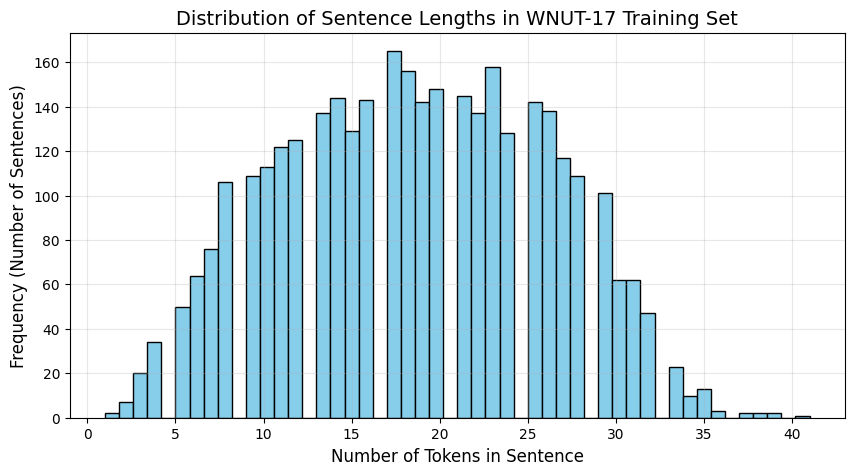

In [32]:
# 1. Sentence Length Histogram (WNUT-17)
plt.figure(figsize=(10, 5))
plt.hist(wnut_train_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Sentence Lengths in WNUT-17 Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)
plt.show()


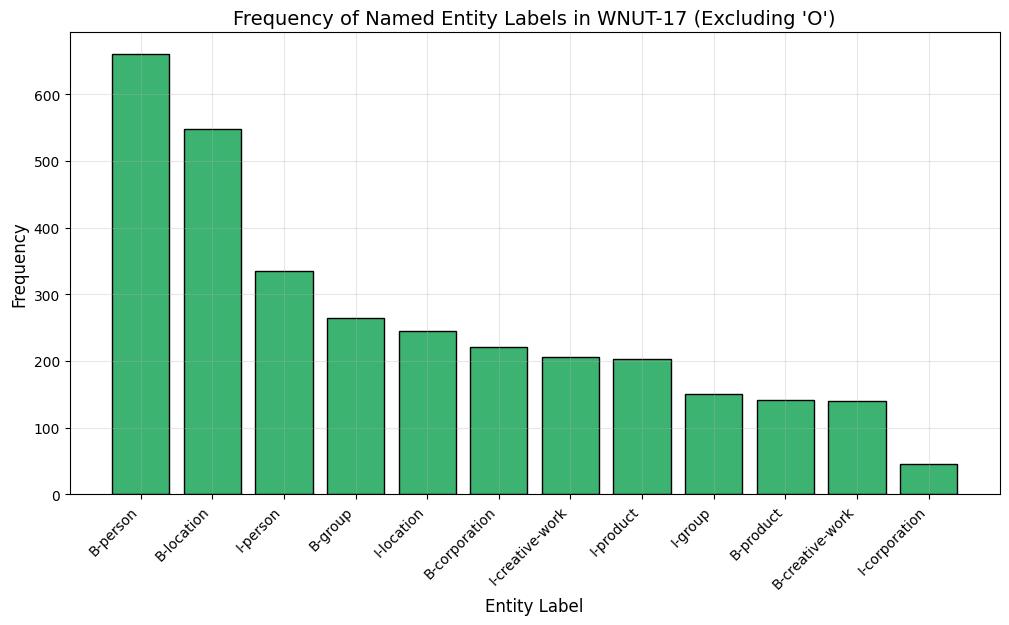

In [33]:
# 2. Entity Label Distribution (WNUT-17, excluding 'O')
wnut_sorted_labels = sorted(wnut_label_counts.items(), key=lambda x: x[1], reverse=True)
wnut_labels, wnut_counts = zip(*wnut_sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(wnut_labels, wnut_counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels in WNUT-17 (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()


**Interpretation:** WNUT-17 sentences are actually **longer on average** than CoNLL-2003 (18.48 tokens vs. 14.50), though with a much lower maximum (41 tokens vs. 113) — the distribution is more tightly clustered rather than long-tailed, consistent with social-media text that has an informal length cap rather than newswire's occasional long, formal sentences. The training set is far smaller (3,394 sentences vs. 14,041) with a proportionally smaller vocabulary (14,878 vs. 23,623 words), which alone makes learning harder. The entity distribution across WNUT-17's six types is heavily skewed: `person` (660 B- + 335 I-) and `location` (548 B- + 245 I-) dominate, `group` and `corporation` are mid-frequency, and `creative-work` and `product` are the rarest, especially at the B- level (140 and 142 respectively) — with so few training examples per type, several categories are essentially data-starved, which is a major reason emerging-entity recognition is hard: the model simply doesn't see enough examples to learn reliable patterns for the rarer classes.


### Feature Engineering for WNUT-17
We reuse the exact same `word2features` function from Task 2 — the orthographic and contextual features (capitalization, prefixes/suffixes, neighboring words) are domain-agnostic and apply equally well to tweets as to newswire text. We only need a WNUT-specific label-conversion helper since the label set is different.


In [34]:
# Label-conversion helper specific to WNUT-17's label set
def sent2labels_wnut(sentence_tags):
    return [wnut_label_names[tag] for tag in sentence_tags]

# Prepare data for the CRF model (reusing word2features / sent2features from Task 2)
print("Extracting features for the WNUT-17 training set...")
X_train_wnut = [sent2features(s) for s in wnut_dataset['train']['tokens']]
y_train_wnut = [sent2labels_wnut(s) for s in wnut_dataset['train']['ner_tags']]

print("Extracting features for the WNUT-17 validation set...")
X_val_wnut = [sent2features(s) for s in wnut_dataset['validation']['tokens']]
y_val_wnut = [sent2labels_wnut(s) for s in wnut_dataset['validation']['ner_tags']]

print("Extracting features for the WNUT-17 test set...")
X_test_wnut = [sent2features(s) for s in wnut_dataset['test']['tokens']]
y_test_wnut = [sent2labels_wnut(s) for s in wnut_dataset['test']['ner_tags']]

print("Feature extraction complete.")


Extracting features for the WNUT-17 training set...
Extracting features for the WNUT-17 validation set...
Extracting features for the WNUT-17 test set...
Feature extraction complete.


### Training the CRF Model on WNUT-17
Same CRF configuration as Task 3, trained from scratch on the WNUT-17 training set.


In [35]:
# Train the CRF Model on WNUT-17
print("Training CRF Model on WNUT-17... (this may take a minute or two)")

crf_wnut = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,           # Coefficient for L1 regularization
    c2=0.1,           # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

crf_wnut.fit(X_train_wnut, y_train_wnut)
print("Model training complete.")


Training CRF Model on WNUT-17... (this may take a minute or two)
Model training complete.


### Model Evaluation on WNUT-17
Same Precision / Recall / F1-score evaluation as Task 3, run on the WNUT-17 test set.


In [36]:
# Predict on the WNUT-17 test set
y_pred_wnut = crf_wnut.predict(X_test_wnut)

# Evaluate on actual entities only (drop 'O')
labels_to_evaluate_wnut = list(crf_wnut.classes_)
if 'O' in labels_to_evaluate_wnut:
    labels_to_evaluate_wnut.remove('O')

print("WNUT-17 Classification Report:\n")
wnut_report = metrics.flat_classification_report(
    y_test_wnut, y_pred_wnut, labels=labels_to_evaluate_wnut, digits=3
)
print(wnut_report)


WNUT-17 Classification Report:

                 precision    recall  f1-score   support

     B-location      0.363     0.247     0.294       150
     I-location      0.414     0.128     0.195        94
        B-group      0.227     0.030     0.053       165
  B-corporation      0.500     0.015     0.029        66
       B-person      0.583     0.140     0.226       429
B-creative-work      0.286     0.028     0.051       142
      B-product      0.250     0.008     0.015       127
       I-person      0.621     0.275     0.381       131
I-creative-work      0.233     0.032     0.056       218
  I-corporation      0.500     0.045     0.083        22
        I-group      0.286     0.057     0.095        70
      I-product      0.200     0.008     0.015       126

      micro avg      0.439     0.097     0.159      1740
      macro avg      0.372     0.084     0.125      1740
   weighted avg      0.388     0.097     0.145      1740



### Visualizing Entity-Wise Performance on WNUT-17


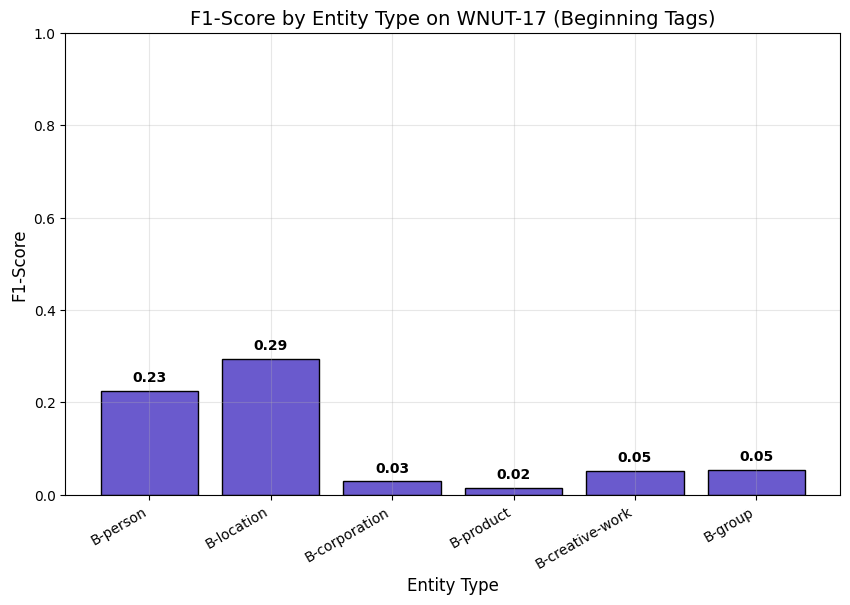

In [37]:
# Extract metrics programmatically for visualization
wnut_report_dict = metrics.flat_classification_report(
    y_test_wnut, y_pred_wnut, labels=labels_to_evaluate_wnut, output_dict=True
)

# Extract B- labels for summary plot
wnut_entities = ['B-person', 'B-location', 'B-corporation', 'B-product', 'B-creative-work', 'B-group']
wnut_entities = [e for e in wnut_entities if e in wnut_report_dict]  # keep only labels present in results
wnut_f1_scores = [wnut_report_dict[ent]['f1-score'] for ent in wnut_entities]

plt.figure(figsize=(10, 6))
plt.bar(wnut_entities, wnut_f1_scores, color='slateblue', edgecolor='black')
plt.title("F1-Score by Entity Type on WNUT-17 (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(wnut_f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


**Interpretation:** Performance collapses relative to CoNLL-2003, exactly as the "emerging entities" framing predicts micro-avg F1 = **0.159** (precision 0.439, recall 0.097) vs. 0.807 on CoNLL-2003. The gap is driven almost entirely by recall: precision is moderate (0.439) but recall is extremely low (0.097), meaning the CRF rarely predicts an entity at all, rather than predicting the wrong type. `I-person` is the strongest class (F1 = **0.381**, precision 0.621, recall 0.275) and `B-person` (F1 = 0.226) is the best-performing B- tag, consistent with person names retaining some orthographic signal (capitalization, name-like tokens) even in noisy text. The weakest classes are `B-product` (F1 = **0.015**, recall 0.008), `I-product` (0.015), `B-corporation` (0.029), and `B-creative-work` (0.051) these categories have the fewest training examples and the least consistent surface form (a product or creative-work name could be almost any capitalized string), so the CRF's memorized lexical features essentially never fire on the held-out test entities, which by design include many names never seen in training.


### Error Analysis on WNUT-17
Same procedure as Task 4: locate mismatched sentences and print token-level true vs. predicted labels.


In [38]:
# Find and display sentences with errors (WNUT-17)
wnut_error_count = 0
print(f"{'Token':<15} | {'True Label':<15} | {'Predicted':<15}")
print("=" * 50)

for i in range(len(y_test_wnut)):
    if y_test_wnut[i] != y_pred_wnut[i]:
        for token, true_lbl, pred_lbl in zip(wnut_test_sentences[i], y_test_wnut[i], y_pred_wnut[i]):
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<15} | {pred_lbl:<15} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<15} | {pred_lbl:<15}")
        print("-" * 50)
        wnut_error_count += 1

    if wnut_error_count >= 3:
        break


Token           | True Label      | Predicted      
&               | O               | O              
gt              | O               | O              
;               | O               | O              
*               | O               | O              
The             | O               | O              
soldier         | O               | O              
was             | O               | O              
killed          | O               | O              
when            | O               | O              
another         | O               | O              
avalanche       | O               | O              
hit             | O               | O              
an              | O               | O              
army            | O               | O              
barracks        | O               | O              
in              | O               | O              
the             | O               | O              
northern        | O               | O              
area        

### Top Error Patterns Observed on WNUT-17
Based on the actual mismatches printed above:

1. **Missed entities entirely, predicted as `O`:** This is overwhelmingly the dominant pattern (matching the very low recall of 0.097). "Sonmarg" (true `B-location`), "Waltengoo Nar" (true `B-location`/`I-location`), "Avalanche Rescue Teams" (true `B-group`/`I-group`/`I-group`), and "ART" (true `B-group`) were all predicted as `O` none of these place or organization names appeared in the training vocabulary, so the CRF's word-identity features gave it nothing to latch onto and it defaulted to the majority class.

2. **Multi-word entity spans collapse completely rather than partially:** Unlike the CoNLL-2003 errors (which were often boundary shifts within an otherwise-detected span), WNUT-17 errors tend to miss the *entire* multi-token entity e.g. all three tokens of "Avalanche Rescue Teams" were tagged `O`. This suggests the model isn't even getting a foothold on the first token of unfamiliar multi-word names, rather than just mis-drawing the boundary.

3. **Unseen proper nouns in informal/OCR-noisy text (note the `&gt;` and `*` tokens):** The presence of raw HTML entities (`&gt;`) and formatting artifacts (`*`) in the tokenized text reflects WNUT-17's noisy, user-generated source data. Combined with place names like "Sonmarg" and "Waltengoo Nar" that are real-world but low-frequency (unlikely to appear in any general-purpose training corpus), this illustrates the core WNUT-17 challenge: entities that are geographically/contextually specific and effectively guaranteed to be out-of-vocabulary for a lexical-feature model.

### Task 6 Summary: CoNLL-2003 vs. WNUT-17
| Aspect | CoNLL-2003 | WNUT-17 |
|---|---|---|
| Text domain | Clean newswire | Noisy social media / user-generated |
| Entity types | 4 (PER, LOC, ORG, MISC) | 6 (person, location, corporation, product, creative-work, group) |
| Train sentences | 14,041 | 3,394 |
| Avg. sentence length | 14.50 tokens | 18.48 tokens |
| Overall micro F1 | **0.807** | **0.159** |
| Overall precision / recall | 0.808 / 0.806 | 0.439 / 0.097 |
| Hardest entity type | `I-MISC` (F1 = 0.661) | `B-product` (F1 = 0.015) |
| Easiest entity type | `I-PER` (F1 = 0.911) | `I-person` (F1 = 0.381) |
| Key takeaway | A feature-based CRF performs well when entities and contexts resemble the training distribution, with performance tracking how consistent each entity type's surface form is. | The same CRF architecture degrades sharply: F1 drops by roughly 5x on novel, emerging entities in noisy text, with the failure mode being *missed detection* (low recall) rather than misclassification. This is exactly the challenge a real customer support system faces with new product names, brands, and locations, reinforcing the Task 5 recommendation to move toward a transformer-based, continuously fine-tuned model for production use. |


---

## Final Summary

* **What was learned:** We built a complete NLP pipeline to extract structured entities from unstructured text, implementing feature engineering and sequence modeling via CRFs, and validated it on two datasets of very different difficulty (CoNLL-2003 and WNUT-17).
* **Importance of NER:** NER bridges the gap between raw text and actionable data, enabling intelligent automation.
* **Key Findings:** The performance gap between the two datasets was large and driven by recall, not precision: CoNLL-2003 achieved micro F1 = 0.807 (precision 0.808, recall 0.806), while WNUT-17 achieved only F1 = 0.159 (precision 0.439, recall 0.097) — roughly a 5x drop. Error analysis confirms the mechanism: on CoNLL-2003 the model mostly confuses entity *types* (LOC vs. PER, ORG vs. MISC) on spans it does detect, while on WNUT-17 the model mostly fails to detect the entity at all, defaulting to `O` for unfamiliar names. This shows that simple contextual and orthographic features (capitalization, neighboring words) are highly predictive on clean, well-represented text, but a feature-based CRF has almost no ability to generalize to novel, unseen entity surface forms — exactly the "emerging entities" problem WNUT-17 is designed to test.
* **Model Strengths:** CRFs are incredibly fast to train, highly interpretable, lightweight to deploy, and model tag transitions well.
* **Model Weaknesses:** Relies entirely on manual feature engineering. Lacks deep contextual understanding (e.g., sarcasm, complex homonyms) compared to neural networks, and generalizes very poorly to entities never seen during training — confirmed empirically by the WNUT-17 results — a critical weakness for a real customer support system where new product names and brands appear constantly.
* **Real-world Applications:** Automated ticket routing, CRM data entry, chatbot intent parsing, and large-scale document redaction (PII removal).
